# Wall Assignment — pure-SAM method (stage 2 of 2)   ·  Colab + Drive

**Method: SAM (no geometric prior).** Second stage of the **pure-SAM** branch: take the room
masks from `notebook_1_sam_auto_segmentation.ipynb` (`stage_sam_auto`) and assign each room
its wall geometry, then back-project to 3-D. This is the **identical boundary-ring wall
assignment** used by `methods/geometric/notebook_2_wall_assignment.ipynb` — only the *mask
source* differs (SAM auto-segmentation masks instead of watershed masks), so the three
methods are compared end-to-end (segmentation **and** resulting walls).

**Runs on Colab + Drive (Option B)** — like notebook 1, but this stage also needs the **point
cloud** (`area1.xyz`) to back-project walls into 3-D, so it reads the cloud from your Drive.

## Inputs (all on Drive / in the repo)
- `wallness.npy` + `transform.json` from `stage1_occupancy` (in `MyDrive/onestruction/out/`).
- `room_labels.npy` from `stage_sam_auto` (written by notebook 1 into the same Drive `out/`).
- The **point cloud** `MyDrive/onestruction/data/area1.xyz` (the SAME cloud that built stage 1).

## Outputs  (`MyDrive/onestruction/out/stage_sam_walls/`, zipped)
- `room_XX_walls.ply` — per-room 3-D wall points.
- `room_wall_masks.npz` — per-room wall-pixel masks (keyed `room_<id>`).
- `room_labels.npy` (the masks used), `transform.json`, `config.json`.

### Setup
**Run-All ready.** The cell below clones `scan2bim`, installs `open3d` (needed to load the
cloud + write PLYs), mounts Drive, and copies `area1.xyz` off Drive to the runtime's fast
local disk. **One-time prerequisite:** upload your point cloud to
`MyDrive/onestruction/data/area1.xyz` (the same cloud that produced stage 1). Edit
`DRIVE_ROOT` / `BRANCH` if yours differ.

In [1]:
# ===== scan2bim setup — Colab + Google Drive (Option B: everything on Colab, no handoff) =====
import sys, os, shutil
import numpy as np

REPO_URL   = 'https://github.com/PrinceofJ/ONESTRUCTION-Point-Cloud-to-BIM.git'
BRANCH     = 'sam-auto-method'
CLONE      = '/content/onestruction'
DRIVE_ROOT = '/content/drive/MyDrive/onestruction'   # <-- your Drive folder (data/area1.xyz + out/)

try:
    import google.colab            # noqa: F401
    IN_COLAB = True
except Exception:
    IN_COLAB = False

def _try_import_scan2bim():
    try:
        import scan2bim
        return scan2bim
    except ModuleNotFoundError:
        return None

scan2bim = _try_import_scan2bim()
if scan2bim is not None:
    PROJECT_DIR = scan2bim.project_root(); SOURCE = 'already on runtime'
elif IN_COLAB:
    if not os.path.isdir(CLONE):
        get_ipython().system(f'git clone --depth 1 -b {BRANCH} {REPO_URL} {CLONE}')
    if not os.path.isdir(os.path.join(CLONE, 'scan2bim')):
        raise RuntimeError(f"Clone failed: push branch '{BRANCH}' first  (git push -u origin {BRANCH}).")
    sys.path.insert(0, CLONE); os.chdir(CLONE)
    import scan2bim; PROJECT_DIR = CLONE; SOURCE = f'git clone ({BRANCH})'
else:
    raise ModuleNotFoundError("scan2bim not importable locally — run `pip install -e .` first.")

from scan2bim import artifacts as A, viz

# open3d (loads the cloud + writes PLYs) isn't on a Colab runtime by default.
if IN_COLAB:
    import importlib.util
    if importlib.util.find_spec('open3d') is None:
        print('installing open3d (one-time)...')
        get_ipython().system('pip install -q open3d')

CLOUD_LOCAL = None
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_ROOT = os.path.join(DRIVE_ROOT, 'out')                 # same Drive out/ as notebook 1
    os.makedirs(OUT_ROOT, exist_ok=True)
    if not (os.path.isfile(A.stage_zip(OUT_ROOT, A.STAGE1)) or  # seed Stage-1 zip if a fresh runtime
            os.path.isdir(A.stage_dir(OUT_ROOT, A.STAGE1))):
        shutil.copy(A.stage_zip(os.path.join(PROJECT_DIR, 'scan2bim_out'), A.STAGE1),
                    A.stage_zip(OUT_ROOT, A.STAGE1))
    # copy the point cloud off Drive to fast local disk (Drive FUSE is slow for ~200 MB)
    CLOUD_DRIVE = os.path.join(DRIVE_ROOT, 'data', 'area1.xyz')
    CLOUD_LOCAL = '/content/area1.xyz'
    if not os.path.exists(CLOUD_LOCAL):
        assert os.path.exists(CLOUD_DRIVE), (
            f'Upload your point cloud to {CLOUD_DRIVE} first '
            f'(the SAME area1.xyz that produced stage 1).')
        print('copying point cloud off Drive to /content (one-time, ~204 MB)...')
        shutil.copy(CLOUD_DRIVE, CLOUD_LOCAL)
else:                                                          # local run
    OUT_ROOT = os.path.join(PROJECT_DIR, 'scan2bim_out')

SHOW_DEBUG = True
print('scan2bim', scan2bim.__version__, '| in_colab:', IN_COLAB, '| source:', SOURCE)
print('OUT_ROOT   :', OUT_ROOT)
print('cloud      :', CLOUD_LOCAL or '(local CFG.file_path)')

scan2bim 1.0.0 | in_colab: False | source: already on runtime
OUT_ROOT   : c:\onestruction\scan2bim_out
cloud      : (local CFG.file_path)


### Step 1 — Load inputs (SAM auto-segmentation masks)
Room masks come from the **pure-SAM** stage 1 (`stage_sam_auto`). The guards below fail loudly
if an upstream stage was produced from a different cloud / grid.

In [2]:
s1 = A.load_stage_dir(OUT_ROOT, A.STAGE1)
wallness = A.load_npy(os.path.join(s1, A.WALLNESS_NPY)).astype(bool)
tf = A.load_transform(os.path.join(s1, A.TRANSFORM_JSON))

# Room masks come from the pure-SAM stage 1 (written by notebook 1 into the same Drive out/).
s_sam = A.load_stage_dir(OUT_ROOT, A.STAGE_SAM_AUTO)

CFG = scan2bim.load_config(start=PROJECT_DIR, out_root=OUT_ROOT)
if CLOUD_LOCAL:
    CFG.file_path = CLOUD_LOCAL                          # the area1.xyz copied off Drive

# Validate same cloud + grid as the upstream stages. Cross-platform file_path guard: the
# stage1 config.json was written on Windows ('c:\...\area1.xyz'), which os.path.basename can't
# split on Linux/Colab -> a spurious mismatch. Pre-equalise file_path ONLY when the basenames
# truly match; every other geometry field (pixel_m, slab, voxel, ...) is still checked strictly.
def _match_fp(up):
    def b(p): return str(p).replace('\\', '/').rsplit('/', 1)[-1]
    return {**up, 'file_path': CFG.file_path} if b(up.get('file_path')) == b(CFG.file_path) else up
scan2bim.assert_upstream_config(CFG, _match_fp(A.load_stage_config(s1)))      # same cloud/grid as stage 1
scan2bim.assert_upstream_config(CFG, _match_fp(A.load_stage_config(s_sam)))   # ...and the SAM stage

labels = A.load_npy(os.path.join(s_sam, A.ROOM_LABELS_NPY)).astype('int32')
print('room masks from: SAM auto (stage_sam_auto) | rooms:',
      len([r for r in np.unique(labels) if r >= 1]))

# Reload the cloud with the SAME loader stage 1 used (deterministic -> aligns to tf), then
# assert it actually lands inside the stage-1 grid.
pcd, pts = scan2bim.load_point_cloud(CFG)
scan2bim.assert_points_in_grid(pts, tf)

room masks from: SAM auto (stage_sam_auto) | rooms: 37
Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
units/meter = 1.0  (raw max extent 48.69)
points before clean: 5,183,987
points after voxel (0.02 m): 5,058,586


0.9994296825239306

### Step 2 — Boundary-ring wall masks (identical to the geometric method)

In [3]:
wall_masks, dbg = scan2bim.room_wall_masks_boundary_ring(labels, wallness, CFG, return_debug=True)
print('rooms:', len(wall_masks), '| erode_px=%d  r_w(dilate_px)=%d' % (dbg['erode_px'], dbg['dilate_px']))

rooms: 37 | erode_px=4  r_w(dilate_px)=5


### Step 3 — Back-project the assigned wall pixels into 3-D

In [4]:
band, floor_z, ceil_z = scan2bim.height_band_mask(pts, CFG, tf)
rooms3d = scan2bim.backproject_room_masks(pts, wall_masks, tf, keep_mask=band)
for e in rooms3d:
    print('room %02d: %7d wall points' % (e['room_id'], len(e['points'])))

room 01:   16442 wall points
room 02:  127648 wall points
room 03:   25928 wall points
room 04:   16918 wall points
room 05:   32265 wall points
room 06:   34630 wall points
room 07:   41116 wall points
room 08:   21422 wall points
room 09:   51655 wall points
room 10:   60322 wall points
room 11:   48290 wall points
room 12:   45791 wall points
room 13:   40097 wall points
room 14:   34357 wall points
room 15:   44855 wall points
room 16:   41045 wall points
room 17:   79121 wall points
room 18:   44585 wall points
room 19:   51448 wall points
room 20:   43867 wall points
room 21:   46185 wall points
room 22:   47440 wall points
room 23:   97855 wall points
room 24:   61761 wall points
room 25:   47305 wall points
room 26:   38218 wall points
room 27:   42685 wall points
room 28:   52159 wall points
room 29:   49564 wall points
room 30:   52590 wall points
room 31:   47363 wall points
room 32:   51596 wall points
room 33:   66950 wall points
room 34:   31879 wall points
room 35:   423

### Optional — QA plot of the boundary-ring assignment

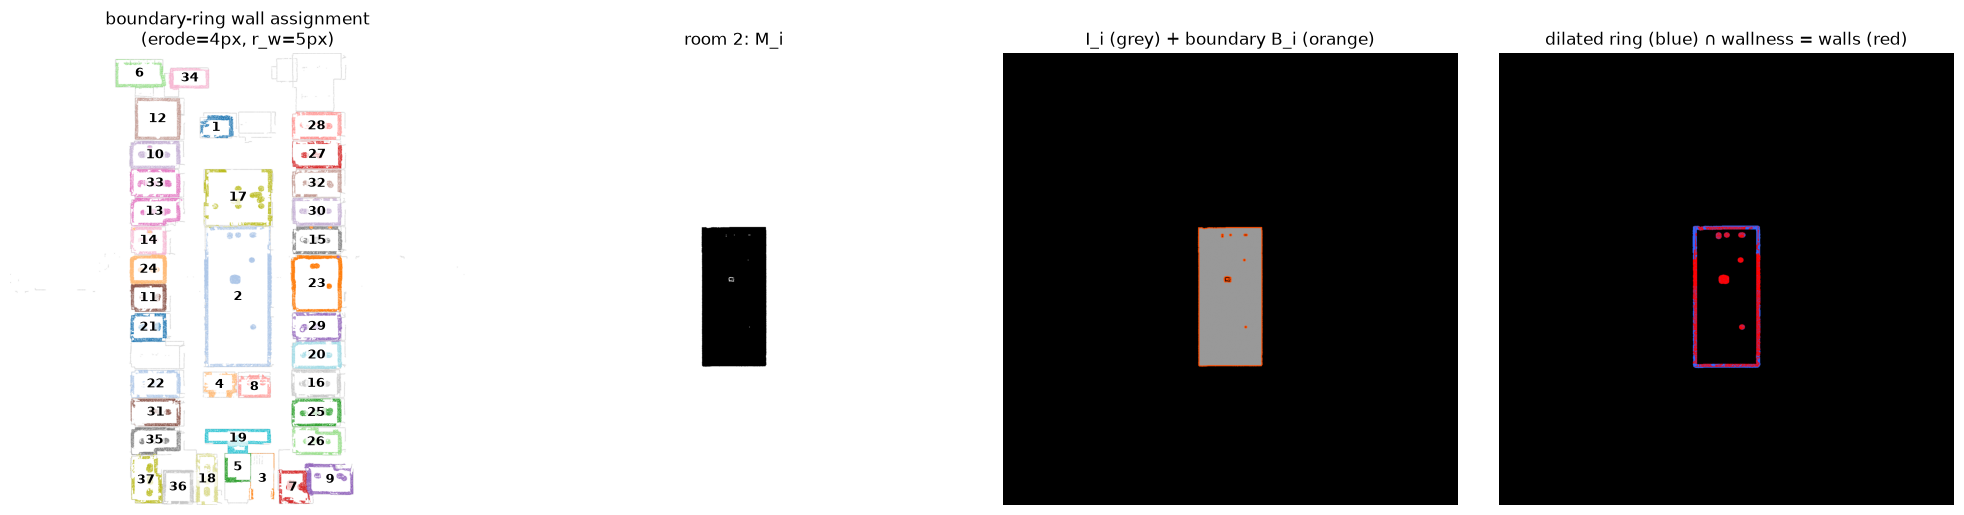

In [5]:
if SHOW_DEBUG:
    viz.show_wall_assignment(labels, wall_masks, debug=dbg)

### Step 4 — Save per-room wall clouds + masks and package the ZIP

In [6]:
import open3d as o3d
# Write the walls to FAST local disk on Colab. The Drive-backed OUT_ROOT is what made this
# save/zip cell crawl (Drive FUSE round-trips on every file flush), so on Colab we write to
# /content (local SSD) and you download stage_sam_walls.zip directly from the VSCode file
# explorer. Locally there's no Drive, so keep writing into the repo's scan2bim_out/.
SAVE_ROOT = A.ensure_dir('/content/out') if IN_COLAB else CFG.out_root
out_dir = A.ensure_dir(A.stage_dir(SAVE_ROOT, A.STAGE_SAM_WALLS))
A.save_room_wall_masks(os.path.join(out_dir, A.ROOM_WALL_MASKS_NPZ), wall_masks)

n_written = 0
for e in rooms3d:
    if len(e['points']) == 0:
        continue
    pc = o3d.geometry.PointCloud()
    pc.points = o3d.utility.Vector3dVector(e['points'])
    o3d.io.write_point_cloud(os.path.join(out_dir, 'room_%02d_walls.ply' % e['room_id']), pc)
    n_written += 1
print('wrote', n_written, 'room wall clouds')

A.save_npy(os.path.join(out_dir, A.ROOM_LABELS_NPY), labels)
A.save_transform(os.path.join(out_dir, A.TRANSFORM_JSON), tf,
                 extra=dict(floor_z=float(floor_z), ceil_z=float(ceil_z)))
A.save_config(os.path.join(out_dir, A.CONFIG_JSON), CFG)
zip_path = A.package_stage(SAVE_ROOT, A.STAGE_SAM_WALLS)
print('packaged ->', zip_path)
print('DOWNLOAD THIS:', zip_path)
print('  (in the VSCode file explorer, browse to it -> right-click -> Download)')

wrote 37 room wall clouds
packaged -> c:\onestruction\scan2bim_out\stage_sam_walls.zip
DOWNLOAD THIS: c:\onestruction\scan2bim_out\stage_sam_walls.zip
  (in the VSCode file explorer, browse to it -> right-click -> Download)


### Output is on Colab's local disk — download it directly
On Colab, `stage_sam_walls` (per-room wall PLYs + masks) is written to **`/content/out/`** (fast
local SSD), **not** Drive — that's what avoids the slow Drive-FUSE save you hit. Grab
`stage_sam_walls.zip` from the **VSCode file explorer** (right-click → Download). On a local run
it just lands in the repo's `scan2bim_out/`.

In [7]:
# Walls were written to FAST local disk (Colab: /content/out; local run: scan2bim_out) -- NOT Drive.
print('stage_sam_walls is at:')
print('   ', A.stage_dir(SAVE_ROOT, A.STAGE_SAM_WALLS), '(room_XX_walls.ply, masks)')
print('   ', A.stage_zip(SAVE_ROOT, A.STAGE_SAM_WALLS), '<- download this from the VSCode file explorer')

stage_sam_walls is at:
    c:\onestruction\scan2bim_out\stage_sam_walls (room_XX_walls.ply, masks)
    c:\onestruction\scan2bim_out\stage_sam_walls.zip <- download this from the VSCode file explorer
